# Statistical vs. Process-Model Forecasting Skill

Compare the Bayesian rate-and-state GMSL–GMST model against IPCC AR6 process-model projections.

**Contents:**
1. Data loading and baseline alignment (year 2000)
2. Observed GMSL + GMST twin-axis time series
3. Two-panel projection comparison with societal impact axes
4. Hindcast cross-validation

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import FuncFormatter
import json
import sys
import os
import warnings

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

from slr_analysis import calibrate_dols, compute_kinematics, resample_to_monthly
from slr_data_readers import (
    people_displaced_kulpstrauss2019,
    slr_cost_jevrejeva2018,
)
from slr_projections import project_gmsl_ensemble, project_gmsl_state_ensemble
from bayesian_dols import solve_state_ode, build_level_design_vectors, fit_bayesian_level

warnings.filterwarnings('ignore', category=FutureWarning)

plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'legend.fontsize': 8,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

M_TO_MM = 1000.0
BASELINE_YEAR = 2000.0
N_SAMPLES = 2000

print('Imports loaded.')

Imports loaded.


## 1. Load Data and Baseline to Year 2000

In [49]:
# ============================================================
# Load all data from HDF5 store
# ============================================================
h5_path = '../data/processed/slr_processed_data.h5'

with pd.HDFStore(h5_path, 'r') as store:
    df_frederikse = store['/harmonized/df_frederikse_h']
    df_berkeley = store['/harmonized/df_berkeley_h']

    temp_projections = {}
    ssp_keys = {
        'SSP1-2.6': 'SSP1_2_6', 'SSP2-4.5': 'SSP2_4_5',
        'SSP3-7.0': 'SSP3_7_0', 'SSP5-8.5': 'SSP5_8_5',
    }
    for name, key in ssp_keys.items():
        temp_projections[name] = store[f'/projections/temp/{key}']

    ipcc_gmsl = {}
    ssp_gmsl_keys = {
        'SSP1-2.6': 'ssp126', 'SSP2-4.5': 'ssp245',
        'SSP3-7.0': 'ssp370', 'SSP5-8.5': 'ssp585',
    }
    for name, key in ssp_gmsl_keys.items():
        ipcc_gmsl[name] = store[f'/projections/gmsl/{key}']

# ============================================================
# Prepare Frederikse GMSL — rebase to year 2000 = 0
# ============================================================
fred_time = df_frederikse['year'].values
fred_gmsl = df_frederikse['gmsl'].values          # meters, baseline 1995-2005
fred_gmsl_sigma = df_frederikse['gmsl_sigma'].values

idx_2000 = np.argmin(np.abs(fred_time - 2000.0))
fred_gmsl_2000 = fred_gmsl[idx_2000]
fred_gmsl_rb = fred_gmsl - fred_gmsl_2000          # year 2000 ≈ 0

print(f'Frederikse: {len(fred_time)} years, '
      f'{fred_time[0]:.0f}–{fred_time[-1]:.0f}')
print(f'GMSL at year 2000 (before rebase): {fred_gmsl_2000*M_TO_MM:.1f} mm')

# ============================================================
# Prepare Berkeley Earth GMST — rebase to year 2000 = 0
# ============================================================
# Annual mean temperature
temp_annual = df_berkeley[['temperature']].resample('YS').mean()
temp_annual['year'] = temp_annual.index.year + 0.5

# 20-year running mean for smoothed view
temp_annual['temp_smooth'] = (
    temp_annual['temperature'].rolling(10, center=True, min_periods=10).mean()
)

# Rebase to year 2000
idx_2000_t = np.argmin(np.abs(temp_annual['year'].values - 2000.0))
temp_at_2000_smooth = temp_annual['temp_smooth'].iloc[idx_2000_t]
temp_at_2000_raw = temp_annual['temperature'].iloc[idx_2000_t]
temp_annual['temp_smooth_rb'] = temp_annual['temp_smooth'] - temp_at_2000_smooth
temp_annual['temperature_rb'] = temp_annual['temperature'] - temp_at_2000_raw

print(f'Berkeley Earth: {len(temp_annual)} years')
print(f'Raw GMST at year 2000: {temp_at_2000_raw:.3f} °C (1995-2005 baseline)')

# ============================================================
# Rebase IPCC GMSL to year 2000 = 0
# ============================================================
# Both Frederikse and IPCC GMSL share the 1995-2005 baseline,
# so we apply the same offset (Frederikse value at year 2000).
# NOTE: np.interp cannot extrapolate to year 2000 because
# IPCC GMSL projections start at 2020.
ipcc_gmsl_rb = {}
for ssp_name, df_ipcc in ipcc_gmsl.items():
    df_rb = df_ipcc.copy()
    for col in ['gmsl', 'gmsl_lower', 'gmsl_upper', 'gmsl_17', 'gmsl_83']:
        if col in df_rb.columns:
            df_rb[col] = df_rb[col] - fred_gmsl_2000
    ipcc_gmsl_rb[ssp_name] = df_rb

print(f'IPCC GMSL rebased using Frederikse offset at yr 2000 = '
      f'{fred_gmsl_2000*M_TO_MM:.1f} mm')

# ============================================================
# Rebase IPCC temperature projections to year 2000 = 0
# ============================================================
# IPCC temperature is on ~1850-1900 (pre-industrial) baseline;
# Berkeley Earth (harmonized) is on the 1995-2005 baseline.
# We compute the offset at their first overlap year so that
# the IPCC projection is continuous with the Berkeley Earth
# observations when rebased to year 2000.
temp_proj_rb = {}
for ssp_name, df_tp in temp_projections.items():
    df_rb = df_tp.copy()
    # Find nearest Berkeley Earth annual value to the first IPCC year
    ipcc_first_year = df_rb['decimal_year'].iloc[0]
    idx_overlap = np.argmin(np.abs(temp_annual['year'].values - ipcc_first_year))
    berk_at_overlap = temp_annual['temperature'].iloc[idx_overlap]
    ipcc_at_overlap = df_rb['temperature'].iloc[0]
    # baseline_offset = IPCC_baseline − Berkeley_baseline
    baseline_offset = ipcc_at_overlap - berk_at_overlap
    # Shift IPCC to Berkeley baseline, then rebase to year 2000
    offset_total = baseline_offset + temp_at_2000_raw
    df_rb['temperature'] = df_rb['temperature'] - offset_total
    if 'temperature_lower' in df_rb.columns:
        df_rb['temperature_lower'] = df_rb['temperature_lower'] - offset_total
        df_rb['temperature_upper'] = df_rb['temperature_upper'] - offset_total
    temp_proj_rb[ssp_name] = df_rb

print(f'IPCC GMST rebased via overlap at year {ipcc_first_year:.0f}: '
      f'Berkeley={berk_at_overlap:.3f}°C, '
      f'IPCC={ipcc_at_overlap:.3f}°C → '
      f'offset={baseline_offset:.3f}°C')

# Verify alignment: IPCC and Berkeley should match at the overlap year
dcheck = temp_proj_rb['SSP2-4.5']
berk_rb_overlap = temp_annual['temperature_rb'].iloc[idx_overlap]
ipcc_rb_overlap = dcheck['temperature'].iloc[0]
print(f'  Check at overlap: Berkeley(rb)={berk_rb_overlap:.3f}°C, '
      f'IPCC(rb)={ipcc_rb_overlap:.3f}°C → '
      f'Δ={ipcc_rb_overlap - berk_rb_overlap:.3f}°C')

print('\nAll data rebased to year 2000 = 0.')

Frederikse: 119 years, 1900–2018
GMSL at year 2000 (before rebase): 0.8 mm
Berkeley Earth: 175 years
Raw GMST at year 2000: -0.121 °C (1995-2005 baseline)
IPCC GMSL rebased using Frederikse offset at yr 2000 = 0.8 mm
IPCC GMST rebased via overlap at year 2015: Berkeley=0.213°C, IPCC=1.110°C → offset=0.898°C
  Check at overlap: Berkeley(rb)=0.334°C, IPCC(rb)=0.333°C → Δ=-0.000°C

All data rebased to year 2000 = 0.


## 2. Load Bayesian Rate-and-State Model

In [50]:
# ============================================================
# Pandas series for hindcast cross-validation (cell 14)
# ============================================================
sl_series = df_frederikse.set_index(
    pd.to_datetime(df_frederikse['year'].astype(int).astype(str) + '-07-01')
)['gmsl']
sl_series.index.name = 'time'

temp_series = df_berkeley['temperature'].resample('MS').first().dropna()

sig_series = df_frederikse.set_index(
    pd.to_datetime(df_frederikse['year'].astype(int).astype(str) + '-07-01')
)['gmsl_sigma']
sig_series.index.name = 'time'

# ============================================================
# Load Bayesian rate-and-state calibration results
# (from bayesian_ratestate.ipynb → bayesian_ratestate_results.json)
# ============================================================
with open('../data/processed/bayesian_ratestate_results.json') as f:
    rs_json = json.load(f)

rs_cal = rs_json['calibration']

# Posterior-mean coefficients: [dα/dT, α₀, trend, d_diseq]  (m/yr)
coeffs_abcd = np.array([
    rs_cal['coefficients_mm_yr']['dalpha_dT'],
    rs_cal['coefficients_mm_yr']['alpha0'],
    rs_cal['coefficients_mm_yr']['trend'],
    rs_cal['coefficients_mm_yr']['d_diseq'],
]) / M_TO_MM   # mm/yr → m/yr

# Approximate posterior covariance from 94% HDI (diagonal)
# For Normal: 94% HDI ≈ mean ± 1.88σ  →  σ = (upper − lower) / 3.76
Z_94 = 1.88
hdi = rs_cal['hdi_94_mm_yr']
sigmas_mm = np.array([
    (hdi['dalpha_dT'][1] - hdi['dalpha_dT'][0]) / (2 * Z_94),
    (hdi['alpha0'][1] - hdi['alpha0'][0]) / (2 * Z_94),
    (hdi['trend'][1] - hdi['trend'][0]) / (2 * Z_94),
    (hdi['d_diseq'][1] - hdi['d_diseq'][0]) / (2 * Z_94),
])
cov_abcd = np.diag((sigmas_mm / M_TO_MM) ** 2)   # m/yr units

# Relaxation time τ — approximate posterior with LogNormal
tau_median = rs_cal['tau_yr']['median']
tau_lo, tau_hi = rs_cal['tau_yr']['hdi_94']
mu_log_tau = np.log(tau_median)
sigma_log_tau = (np.log(tau_hi) - np.log(tau_lo)) / (2 * Z_94)
rng_tau = np.random.default_rng(123)
tau_samples = rng_tau.lognormal(mu_log_tau, sigma_log_tau, size=4000)

# ============================================================
# Full monthly temperature record (for ODE spin-up)
# ============================================================
T_monthly_all = df_berkeley['temperature'].values
time_monthly_all = np.array([
    t.year + (t.month - 0.5) / 12 for t in df_berkeley.index
])

# ============================================================
# Reconstruct posterior-mean model fit (H_model_mean)
# Replicates state_result.H_model_mean from bayesian_ratestate.ipynb
# ============================================================
mask_fit = ((time_monthly_all >= fred_time[0]) &
            (time_monthly_all <= fred_time[-1]))
T_monthly_fit = T_monthly_all[mask_fit]
time_monthly_fit = time_monthly_all[mask_fit]

# Solve state-variable ODE with median τ
S_fit = solve_state_ode(T_monthly_fit, time_monthly_fit, tau_median)

# Monthly rate = a·T² + b·T + c + d·(S − T)
a, b, c, d = coeffs_abcd
rate_monthly = (a * T_monthly_fit**2 + b * T_monthly_fit + c
                + d * (S_fit - T_monthly_fit))

# Integrate rate → GMSL on monthly grid
dt_monthly = np.diff(time_monthly_fit)
H_monthly = np.zeros(len(T_monthly_fit))
for i in range(len(dt_monthly)):
    H_monthly[i + 1] = (H_monthly[i]
                         + 0.5 * (rate_monthly[i] + rate_monthly[i + 1])
                         * dt_monthly[i])

# Sample at annual observation times
obs_idx_monthly = np.array([
    np.argmin(np.abs(time_monthly_fit - t)) for t in fred_time
])
H_model_at_obs = H_monthly[obs_idx_monthly]

# Least-squares offset H₀ to match observations
H0_fit = np.mean(fred_gmsl - H_model_at_obs)
H_model_mean = H_model_at_obs + H0_fit          # meters, 1995-2005 baseline

# Rebase to year 2000 = 0
H_model_mean_rb = H_model_mean - H_model_mean[idx_2000]

# R² against observations
ss_res = np.sum((fred_gmsl_rb - H_model_mean_rb)**2)
ss_tot = np.sum((fred_gmsl_rb - np.mean(fred_gmsl_rb))**2)
r2_model = 1 - ss_res / ss_tot

print('Bayesian rate-and-state model (from JSON):')
print(f'  dα/dT     = {coeffs_abcd[0]*M_TO_MM:.3f} mm/yr/°C²')
print(f'  α₀        = {coeffs_abcd[1]*M_TO_MM:.3f} mm/yr/°C')
print(f'  trend     = {coeffs_abcd[2]*M_TO_MM:.3f} mm/yr')
print(f'  d (diseq) = {coeffs_abcd[3]*M_TO_MM:.3f} mm/yr/°C')
print(f'  τ median  = {tau_median:.1f} yr')
print(f'  R²        = {r2_model:.4f}')

Bayesian rate-and-state model (from JSON):
  dα/dT     = 4.625 mm/yr/°C²
  α₀        = 5.171 mm/yr/°C
  trend     = 2.632 mm/yr
  d (diseq) = 0.532 mm/yr/°C
  τ median  = 18.2 yr
  R²        = 0.9665


In [51]:
# ============================================================
# Build temperature scenarios for rate-and-state projection
# ============================================================
# Use temperatures in the SAME baseline as calibration
# (Berkeley Earth 1995-2005 baseline), NOT the year-2000 rebase.
# The rate polynomial was calibrated with these temperatures;
# evaluating at shifted temps biases the quadratic term.

# Historical: original Berkeley Earth (1995-2005 baseline)
temp_annual_for_proj = temp_annual[['temperature']].copy()
temp_annual_for_proj['decimal_year'] = temp_annual['year'].values

# IPCC SSP: shift from pre-industrial to Berkeley Earth 1995-2005
# baseline (subtract only the inter-baseline offset)
full_temp_scenarios = {}
for ssp_name, df_tp in temp_projections.items():
    df_cal = df_tp.copy()
    ipcc_first_year = df_cal['decimal_year'].iloc[0]
    idx_ov = np.argmin(np.abs(temp_annual['year'].values - ipcc_first_year))
    berk_ov = temp_annual['temperature'].iloc[idx_ov]
    ipcc_ov = df_cal['temperature'].iloc[0]
    cal_offset = ipcc_ov - berk_ov    # pre-industrial → 1995-2005
    df_cal['temperature'] = df_cal['temperature'] - cal_offset

    # Merge historical observed + IPCC projected
    hist = temp_annual_for_proj[
        temp_annual_for_proj['decimal_year'] < df_cal['decimal_year'].iloc[0]
    ].copy()
    proj = df_cal[['temperature', 'decimal_year']].copy()
    combined = pd.concat([hist, proj], ignore_index=False)
    combined = combined.sort_values('decimal_year').reset_index(drop=True)
    combined.index = pd.to_datetime(
        combined['decimal_year'].astype(int).astype(str) + '-01-01'
    )
    full_temp_scenarios[ssp_name] = combined

# Select from year 2000 onward for the projection grid;
# project_gmsl_state_ensemble prepends historical_temperature
# for ODE spin-up automatically.
temp_proj_from_2000 = {}
for ssp_name, combined in full_temp_scenarios.items():
    mask = combined['decimal_year'] >= BASELINE_YEAR
    temp_proj_from_2000[ssp_name] = combined[mask].copy()

# ============================================================
# Run rate-and-state ensemble projection
# ============================================================
mc_results = project_gmsl_state_ensemble(
    coefficients=coeffs_abcd,
    coefficients_cov=cov_abcd,
    tau_samples=tau_samples,
    temperature_projections=temp_proj_from_2000,
    historical_temperature=T_monthly_all,
    historical_time=time_monthly_all,
    baseline_year=BASELINE_YEAR,
    baseline_gmsl=0.0,
    n_samples=N_SAMPLES,
    seed=42,
)

print('Rate-and-state projections computed for:',
      list(mc_results['scenarios'].keys()))

# Verify: temperature at overlap should match Berkeley Earth
check_df = full_temp_scenarios['SSP2-4.5']
idx_chk = np.argmin(np.abs(check_df['decimal_year'].values - 2015))
berk_chk = temp_annual['temperature'].iloc[
    np.argmin(np.abs(temp_annual['year'].values - 2015))
]
print(f'  Temp check at 2015: Berkeley={berk_chk:.3f}°C, '
      f'IPCC(cal baseline)={check_df["temperature"].iloc[idx_chk]:.3f}°C')

Rate-and-state projections computed for: ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']
  Temp check at 2015: Berkeley=0.213°C, IPCC(cal baseline)=0.213°C


## 3. Quadratic Extrapolation of Observations

In [54]:
# ============================================================
# Extrapolate Frederikse GMSL using compute_kinematics()
# ============================================================
# Use kernel-weighted local polynomial regression (30-yr bandwidth)
# to estimate rate and acceleration at the end of the record,
# then extrapolate with a quadratic:
#   H(t) = H_end + rate_end*(t - t_end) + ½*accel_end*(t - t_end)²

EXTRAP_BW = 30  # bandwidth in years for kinematics

kin = compute_kinematics(
    time=fred_time,
    value=fred_gmsl_rb,
    sigma=fred_gmsl_sigma,
    span_years=EXTRAP_BW,
)

# Values at end of record
rate_end = kin.rate[-1]          # m/yr
rate_se_end = kin.rate_se[-1]
accel_end = kin.accel[-1]        # m/yr²
accel_se_end = kin.accel_se[-1]
t_end = kin.time[-1]
H_end = fred_gmsl_rb[-1]

print(f'Kinematics at {t_end:.0f} (bw={EXTRAP_BW} yr):')
print(f'  Rate  = {rate_end*M_TO_MM:.2f} ± {rate_se_end*M_TO_MM:.2f} mm/yr')
print(f'  Accel = {accel_end*M_TO_MM:.4f} ± {accel_se_end*M_TO_MM:.4f} mm/yr²')

# Build extrapolation time axis
t_extrap = np.arange(fred_time[0], 2101, dtype=float)
dt_extrap = t_extrap - t_end

# Quadratic extrapolation from kinematics
quad_extrap = np.where(
    t_extrap <= t_end,
    np.interp(t_extrap, fred_time, fred_gmsl_rb),          # use obs where available
    H_end + rate_end * dt_extrap + 0.5 * accel_end * dt_extrap**2,
)

# Monte Carlo CI: propagate rate and acceleration uncertainty
rng = np.random.default_rng(42)
n_boot = 2000
quad_boot = np.zeros((n_boot, len(t_extrap)))
for k in range(n_boot):
    r_k = rng.normal(rate_end, rate_se_end)
    a_k = rng.normal(accel_end, accel_se_end)
    quad_boot[k] = np.where(
        t_extrap <= t_end,
        np.interp(t_extrap, fred_time, fred_gmsl_rb),
        H_end + r_k * dt_extrap + 0.5 * a_k * dt_extrap**2,
    )
quad_p5 = np.percentile(quad_boot, 5, axis=0)
quad_p95 = np.percentile(quad_boot, 95, axis=0)

print(f'Extrapolated GMSL at 2075: '
      f'{np.interp(2075, t_extrap, quad_extrap)*M_TO_MM:.0f} mm '
      f'[{np.interp(2075, t_extrap, quad_p5)*M_TO_MM:.0f}–'
      f'{np.interp(2075, t_extrap, quad_p95)*M_TO_MM:.0f}]')

Kinematics at 2018 (bw=30 yr):
  Rate  = 5.10 ± 0.57 mm/yr
  Accel = 0.1646 ± 0.0533 mm/yr²
Extrapolated GMSL at 2075: 624 mm [464–776]


## 4. Observed GMSL + GMST Twin-Axis Time Series

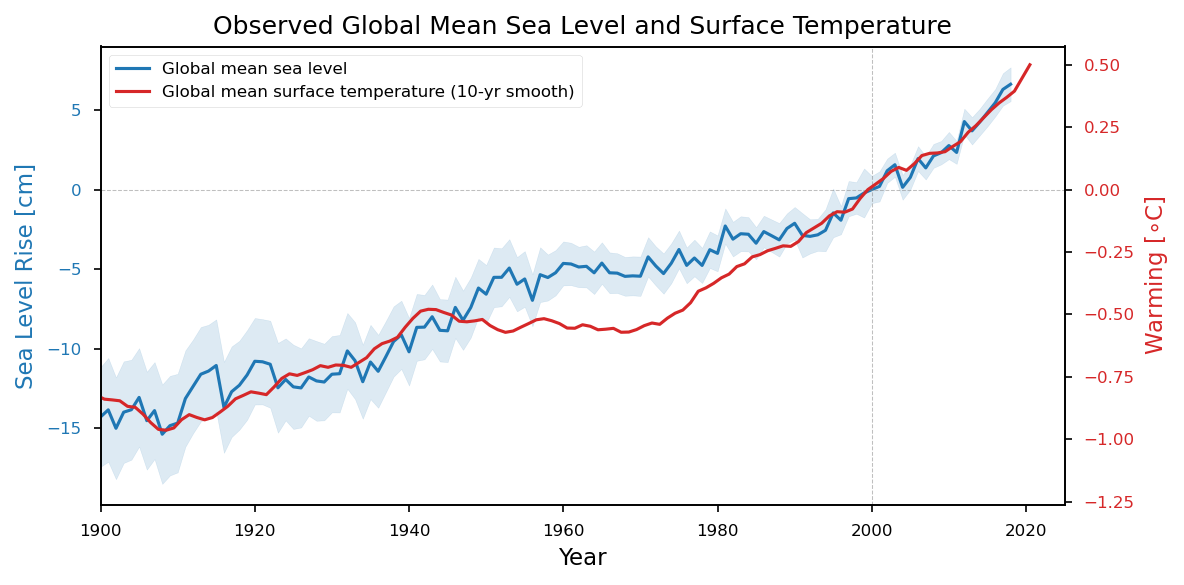

Figure 1 saved.


In [55]:
# ============================================================
# Figure 1: Frederikse GMSL + Berkeley Earth GMST (20-yr smooth)
# ============================================================
fig, ax1 = plt.subplots(figsize=(8, 4))

# GMSL on left y-axis
unit_convert = 100.
ax1.plot(fred_time, fred_gmsl_rb*unit_convert, color='tab:blue', linewidth=1.5,
         label='Global mean sea level')
ax1.fill_between(fred_time,
                 unit_convert*(fred_gmsl_rb - 1.645 * fred_gmsl_sigma),
                 unit_convert*(fred_gmsl_rb + 1.645 * fred_gmsl_sigma),
                 color='tab:blue', alpha=0.15)#, label='90% CI')
ax1.set_xlabel('Year')
ax1.set_ylabel('Sea Level Rise [cm]',
               color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.axhline(0, color='gray', ls='--', lw=0.5, alpha=0.5)
ax1.axvline(BASELINE_YEAR,color='gray', ls='--', lw=0.5, alpha=0.5)

# GMST on right y-axis
ax2 = ax1.twinx()
mask_smooth = temp_annual['temp_smooth_rb'].notna()
ax2.plot(temp_annual['year'].values[mask_smooth],
         temp_annual['temp_smooth_rb'].values[mask_smooth],
         color='tab:red', linewidth=1.5, linestyle='-',
         label='Global mean surface temperature (10-yr smooth)')
ax2.set_ylabel(r'Warming [$\circ$C]',
               color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left',
           frameon=True, framealpha=0.9)

# Align y = 0 on both axes to the same horizontal position
sl_lo, sl_hi = ax1.get_ylim()
t_lo, t_hi = ax2.get_ylim()
# Fraction of zero from bottom for each axis
f_sl = -sl_lo / (sl_hi - sl_lo)
f_t  = -t_lo / (t_hi - t_lo)
# Expand the axis whose zero is closer to the bottom
if f_sl > f_t:
    # Push GMST lower limit down so its zero matches GMSL's
    new_t_lo = -f_sl / (1 - f_sl) * t_hi
    ax2.set_ylim(new_t_lo, t_hi)
else:
    # Push GMSL lower limit down so its zero matches GMST's
    new_sl_lo = -f_t / (1 - f_t) * sl_hi
    ax1.set_ylim(new_sl_lo, sl_hi)

ax1.set_xlim(1900, 2025)
ax1.set_title('Observed Global Mean Sea Level and Surface Temperature')
fig.tight_layout()
fig.savefig('../figures/stats_v_process_fig1_observations.png',
            dpi=200, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

## 5. Two-Panel Projection Plot with Societal Impact Axes

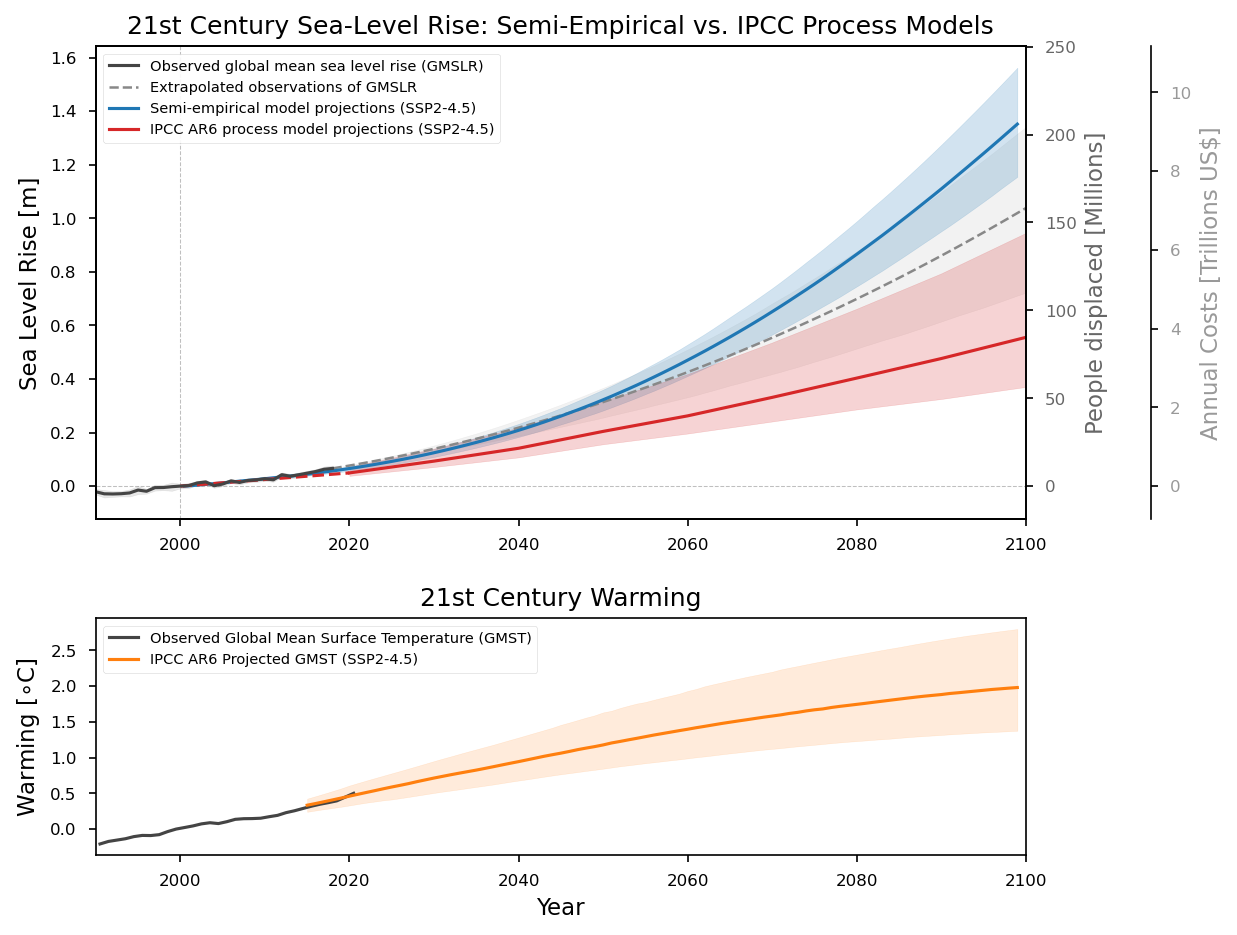

Figure 2 saved.


In [63]:
# ============================================================
# Figure 2: Two-panel projection plot
# Upper: GMSL projections + impact axes
# Lower: GMST observations + IPCC projections
# ============================================================

# --- Ensure kinematics extrapolation variables exist (from cell 8) ---
if 't_end' not in dir():
    EXTRAP_BW = 30
    kin = compute_kinematics(
        time=fred_time, value=fred_gmsl_rb,
        sigma=fred_gmsl_sigma, span_years=EXTRAP_BW,
    )
    rate_end = kin.rate[-1]
    rate_se_end = kin.rate_se[-1]
    accel_end = kin.accel[-1]
    accel_se_end = kin.accel_se[-1]
    t_end = kin.time[-1]
    H_end = fred_gmsl_rb[-1]
    t_extrap = np.arange(fred_time[0], 2101, dtype=float)
    dt_extrap = t_extrap - t_end
    quad_extrap = np.where(
        t_extrap <= t_end,
        np.interp(t_extrap, fred_time, fred_gmsl_rb),
        H_end + rate_end * dt_extrap + 0.5 * accel_end * dt_extrap**2,
    )
    rng = np.random.default_rng(42)
    n_boot = 2000
    quad_boot = np.zeros((n_boot, len(t_extrap)))
    for k in range(n_boot):
        r_k = rng.normal(rate_end, rate_se_end)
        a_k = rng.normal(accel_end, accel_se_end)
        quad_boot[k] = np.where(
            t_extrap <= t_end,
            np.interp(t_extrap, fred_time, fred_gmsl_rb),
            H_end + r_k * dt_extrap + 0.5 * a_k * dt_extrap**2,
        )
    quad_p5 = np.percentile(quad_boot, 5, axis=0)
    quad_p95 = np.percentile(quad_boot, 95, axis=0)
    print(f'[auto-computed kinematics: rate={rate_end*M_TO_MM:.2f} mm/yr, '
          f'accel={accel_end*M_TO_MM:.4f} mm/yr²]')

# --- User-adjustable parameters ---
YEAR_START = 1990
YEAR_END = 2100
SSP = 'SSP2-4.5'
COLOR_OBS = '#444444'          # dark grey for observations
COLOR_EXTRAP = '#888888'       # lighter grey for extrapolation
COLOR_RS = 'tab:blue'          # Rate-and-state model
COLOR_IPCC = 'tab:red'         # IPCC process models
COLOR_GMST = 'tab:orange'      # GMST
ALPHA_CI = 0.2

fig = plt.figure(figsize=(8, 7))
gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1], hspace=0.28)

# ==================== UPPER PANEL: GMSL ====================
ax_sl = fig.add_subplot(gs[0])

ax_sl.axhline(0, color='gray', ls='--', lw=0.5, alpha=0.5)
ax_sl.axvline(BASELINE_YEAR,color='gray', ls='--', lw=0.5, alpha=0.5)

# Frederikse observations
mask_obs = (fred_time >= YEAR_START) & (fred_time <= YEAR_END)
ax_sl.plot(fred_time[mask_obs], fred_gmsl_rb[mask_obs],
           color=COLOR_OBS, linewidth=1.5, label='Observed global mean sea level rise (GMSLR)', zorder=10)
ax_sl.fill_between(fred_time[mask_obs],
                   fred_gmsl_rb[mask_obs] - 1.645 * fred_gmsl_sigma[mask_obs],
                   fred_gmsl_rb[mask_obs] + 1.645 * fred_gmsl_sigma[mask_obs],
                   color=COLOR_OBS, alpha=0.12)

# Kinematics extrapolation (dashed, beyond end of data only)
mask_ext = (t_extrap >= t_end) & (t_extrap <= YEAR_END)
ax_sl.plot(t_extrap[mask_ext], quad_extrap[mask_ext],
           color=COLOR_EXTRAP, linewidth=1.2, linestyle='--',
           label='Extrapolated observations of GMSLR')
ax_sl.fill_between(t_extrap[mask_ext], quad_p5[mask_ext], quad_p95[mask_ext],
                   color=COLOR_EXTRAP, alpha=0.1)

# Rate-and-state posterior mean projection
rs_df = mc_results['scenarios'][SSP]
rs_time = rs_df['decimal_year'].values
mask_rs = (rs_time >= YEAR_START) & (rs_time <= YEAR_END)
ax_sl.plot(rs_time[mask_rs], rs_df['gmsl'].values[mask_rs],
           color=COLOR_RS, linewidth=1.5,
           label=f'Semi-empirical model projections ({SSP})')
ax_sl.fill_between(rs_time[mask_rs],
                   rs_df['gmsl_lower'].values[mask_rs],
                   rs_df['gmsl_upper'].values[mask_rs],
                   color=COLOR_RS, alpha=ALPHA_CI)

# IPCC process-model projection
ipcc_df = ipcc_gmsl_rb[SSP]
ipcc_time = ipcc_df['decimal_year'].values
mask_ipcc = (ipcc_time >= YEAR_START) & (ipcc_time <= 2100)
ax_sl.plot(ipcc_time[mask_ipcc], ipcc_df['gmsl'].values[mask_ipcc],
           color=COLOR_IPCC, linewidth=1.5,
           label=f'IPCC AR6 process model projections ({SSP})')
ax_sl.fill_between(ipcc_time[mask_ipcc],
                   ipcc_df['gmsl_lower'].values[mask_ipcc],
                   ipcc_df['gmsl_upper'].values[mask_ipcc],
                   color=COLOR_IPCC, alpha=ALPHA_CI)

# IPCC hindcast: dashed line from baseline (year 2000, 0) to first projection point
ax_sl.plot([2000, ipcc_time[mask_ipcc][0]],
           [0.0, ipcc_df['gmsl'].values[mask_ipcc][0]],
           color=COLOR_IPCC, linewidth=1.5, linestyle='--')

ax_sl.set_xlim(YEAR_START, YEAR_END)
ax_sl.set_ylabel('Sea Level Rise [m]')
ax_sl.legend(loc='upper left', fontsize=7, frameon=True, framealpha=0.9)
ax_sl.set_title(f'21st Century Sea-Level Rise: Semi-Empirical vs. IPCC Process Models')


# --- Right axis 1: People exposed (from Kulp & Strauss 2019) ---
# Linear scaling baselined to zero at SLR = 0 (baseline year),
# so impact axes read 0 at the baseline regardless of YEAR_START.
pop_baseline = people_displaced_kulpstrauss2019(0.0)
ax_pop = ax_sl.twinx()
sl_lo, sl_hi = ax_sl.get_ylim()
pop_at_hi = people_displaced_kulpstrauss2019(sl_hi) - pop_baseline
pop_scale = pop_at_hi / sl_hi if sl_hi > 0 else 0
ax_pop.set_ylim(pop_scale * sl_lo, pop_scale * sl_hi)
ax_pop.set_ylabel('People displaced [Millions]', color='#666666')
ax_pop.tick_params(axis='y', labelcolor='#666666')
ax_pop.spines['right'].set_position(('outward', 0))

# --- Right axis 2: Annual flood cost (from Jevrejeva 2018) ---
ax_cost = ax_sl.twinx()
ax_cost.spines['right'].set_position(('outward', 60))
cost_at_hi = 0.45e-3 * slr_cost_jevrejeva2018(sl_hi)
cost_scale = cost_at_hi / sl_hi if sl_hi > 0 else 0
ax_cost.set_ylim(cost_scale * sl_lo, cost_scale * sl_hi)
ax_cost.set_ylabel('Annual Costs [Trillions US\\$]', color='#999999')
ax_cost.tick_params(axis='y', labelcolor='#999999')

# ==================== LOWER PANEL: GMST ====================
ax_t = fig.add_subplot(gs[1], sharex=ax_sl)

# Observed 20-yr smoothed GMST
mask_ts = (temp_annual['year'].values >= YEAR_START) & \
          (temp_annual['year'].values <= YEAR_END) & \
          temp_annual['temp_smooth_rb'].notna()
ax_t.plot(temp_annual['year'].values[mask_ts],
          temp_annual['temp_smooth_rb'].values[mask_ts],
          color=COLOR_OBS, linewidth=1.5,
          label='Observed Global Mean Surface Temperature (GMST)')

# IPCC SSP temperature projection
tp_df = temp_proj_rb[SSP]
tp_time = tp_df['decimal_year'].values
mask_tp = (tp_time >= YEAR_START) & (tp_time <= YEAR_END)
ax_t.plot(tp_time[mask_tp], tp_df['temperature'].values[mask_tp],
          color=COLOR_GMST, linewidth=1.5, linestyle='-',
          label=f'IPCC AR6 Projected GMST ({SSP})')
if 'temperature_lower' in tp_df.columns:
    ax_t.fill_between(tp_time[mask_tp],
                      tp_df['temperature_lower'].values[mask_tp],
                      tp_df['temperature_upper'].values[mask_tp],
                      color=COLOR_GMST, alpha=0.15)

ax_t.set_title(f"21st Century Warming")
ax_t.set_xlabel('Year')
ax_t.set_ylabel(r'Warming [$\circ$C]')
ax_t.legend(loc='upper left', fontsize=7, frameon=True, framealpha=0.9)

fig.savefig('../figures/stats_v_process_fig2_projections.png',
            dpi=200, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

## 6. Hindcast Cross-Validation

In [68]:
# ============================================================
# Hindcast: calibrate on truncated records, project forward
# using observed Berkeley Earth temperatures (not SSPs)
# ============================================================

HINDCAST_START_YEAR = 1920
CUTOFF_YEARS = [2000, 2010, 2018]
HINDCAST_COLORS = {2000: 'tab:green', 2010: 'tab:purple', 2018: 'tab:orange'}
PLOT_YEAR_START = 1975
PLOT_YEAR_END = 2100

# --- Bayesian level-space priors (matching bayesian_ratestate.ipynb) ---
PRIOR_SCALE_A = 0.005 / np.log(10)    # ~0.00217 m/yr/°C²; P(a > 5 mm/yr/°C²) = 10%
PRIOR_SCALE_B = 0.010                  # HalfNormal sigma for b
PRIOR_C_MEAN  = 0.002                  # Normal mean for c (trend)
PRIOR_C_SIGMA = 0.005                  # Normal sigma for c
PRIOR_SIGMA_EXTRA_SCALE = 0.005        # HalfCauchy(5 mm)
PRIOR_H0_SIGMA = 0.050                # Normal sigma for H₀ (50 mm)

# Observed temperature for forward projection — use calibration
# baseline (1995-2005), NOT year-2000 rebase, to be consistent
# with DOLS coefficients
temp_for_proj = temp_annual[['temperature']].copy()
temp_for_proj['decimal_year'] = temp_annual['year'].values

# Build observed + SSP2-4.5 temperature for projection beyond obs
# Shift IPCC from pre-industrial to Berkeley Earth 1995-2005 baseline
tp_ssp_cal = temp_projections[SSP].copy()
ipcc_fy = tp_ssp_cal['decimal_year'].iloc[0]
idx_ov = np.argmin(np.abs(temp_annual['year'].values - ipcc_fy))
cal_off = tp_ssp_cal['temperature'].iloc[0] - temp_annual['temperature'].iloc[idx_ov]
tp_ssp_cal['temperature'] = tp_ssp_cal['temperature'] - cal_off

temp_proj_combined = pd.concat([
    temp_for_proj[temp_for_proj['decimal_year'] < tp_ssp_cal['decimal_year'].iloc[0]],
    tp_ssp_cal[['temperature', 'decimal_year']]
], ignore_index=True)
temp_proj_combined.index = pd.to_datetime(
    temp_proj_combined['decimal_year'].astype(int).astype(str) + '-01-01'
)

hindcast_results = {}

for cut_yr in CUTOFF_YEARS:
    # --- Truncate calibration data to <= cut_yr ---
    obs_mask_cal = fred_time <= cut_yr
    obs_years_cal = fred_time[obs_mask_cal]
    H_obs_cal = fred_gmsl[obs_mask_cal]            # native baseline (meters)
    sigma_cal = fred_gmsl_sigma[obs_mask_cal]

    if len(obs_years_cal) < 50:
        print(f'Skipping cutoff {cut_yr}: insufficient data')
        continue

    # --- Monthly temperature for calibration period ---
    mask_monthly = ((time_monthly_all >= obs_years_cal[0]) &
                    (time_monthly_all <= obs_years_cal[-1] + 0.99))
    T_monthly_cal = T_monthly_all[mask_monthly]
    time_monthly_cal = time_monthly_all[mask_monthly]

    # --- Build design vectors ---
    dv = build_level_design_vectors(
        temperature_monthly=T_monthly_cal,
        time_monthly=time_monthly_cal,
        obs_times=obs_years_cal,
    )

    # --- Fit Bayesian level-space model ---
    try:
        result_trunc = fit_bayesian_level(
            H_obs=H_obs_cal,
            sigma_obs=sigma_cal,
            I2_obs=dv['I2_obs'],
            I1_obs=dv['I1_obs'],
            I0_obs=dv['I0_obs'],
            prior_scale_a=PRIOR_SCALE_A,
            prior_scale_b=PRIOR_SCALE_B,
            prior_c_mean=PRIOR_C_MEAN,
            prior_c_sigma=PRIOR_C_SIGMA,
            prior_sigma_extra_scale=PRIOR_SIGMA_EXTRA_SCALE,
            prior_H0_sigma=PRIOR_H0_SIGMA,
            n_samples=2000,
            n_walkers=32,
            n_burnin=1000,
            progress=False,
            seed=42,
        )
    except Exception as e:
        print(f'Calibration failed for cutoff {cut_yr}: {e}')
        continue

    coeffs_trunc = result_trunc.physical_coefficients
    cov_trunc = result_trunc.physical_covariance

    # Project with observed + SSP temperatures (calibration baseline)
    mc_hind = project_gmsl_ensemble(
        coefficients=coeffs_trunc,
        coefficients_cov=cov_trunc,
        temperature_projections={'projection': temp_proj_combined},
        baseline_year=BASELINE_YEAR,
        baseline_gmsl=0.0,
        n_samples=N_SAMPLES,
        seed=42,
    )
    hind_df = mc_hind['scenarios']['projection']

    # Compute verification statistics against held-out obs
    obs_mask = (fred_time > cut_yr) & (fred_time <= fred_time[-1])
    if obs_mask.sum() > 0:
        hind_time = hind_df['decimal_year'].values
        pred_at_obs = np.interp(fred_time[obs_mask], hind_time,
                                hind_df['gmsl'].values)
        pred_lo = np.interp(fred_time[obs_mask], hind_time,
                            hind_df['gmsl_lower'].values)
        pred_hi = np.interp(fred_time[obs_mask], hind_time,
                            hind_df['gmsl_upper'].values)
        resid = fred_gmsl_rb[obs_mask] - pred_at_obs
        rmse = np.sqrt(np.mean(resid**2)) * M_TO_MM
        bias = np.mean(resid) * M_TO_MM
        coverage = np.mean(
            (fred_gmsl_rb[obs_mask] >= pred_lo) &
            (fred_gmsl_rb[obs_mask] <= pred_hi)
        )
    else:
        rmse, bias, coverage = np.nan, np.nan, np.nan

    hindcast_results[cut_yr] = {
        'result': result_trunc,
        'projection': hind_df,
        'rmse_mm': rmse,
        'bias_mm': bias,
        'coverage_90': coverage,
    }

    print(f'Cutoff {cut_yr}: '
          f'dα/dT={coeffs_trunc[0]*M_TO_MM:.3f}, '
          f'α₀={coeffs_trunc[1]*M_TO_MM:.3f}, '
          f'trend={coeffs_trunc[2]*M_TO_MM:.3f}  |  '
          f'RMSE={rmse:.1f} mm, Bias={bias:.1f} mm, '
          f'90% Coverage={coverage:.0%}')

Cutoff 2000: dα/dT=1.806, α₀=1.634, trend=1.622  |  RMSE=15.5 mm, Bias=11.3 mm, 90% Coverage=22%
Cutoff 2010: dα/dT=3.535, α₀=3.996, trend=2.336  |  RMSE=8.6 mm, Bias=5.8 mm, 90% Coverage=38%
Cutoff 2018: dα/dT=4.820, α₀=5.209, trend=2.532  |  RMSE=nan mm, Bias=nan mm, 90% Coverage=nan%


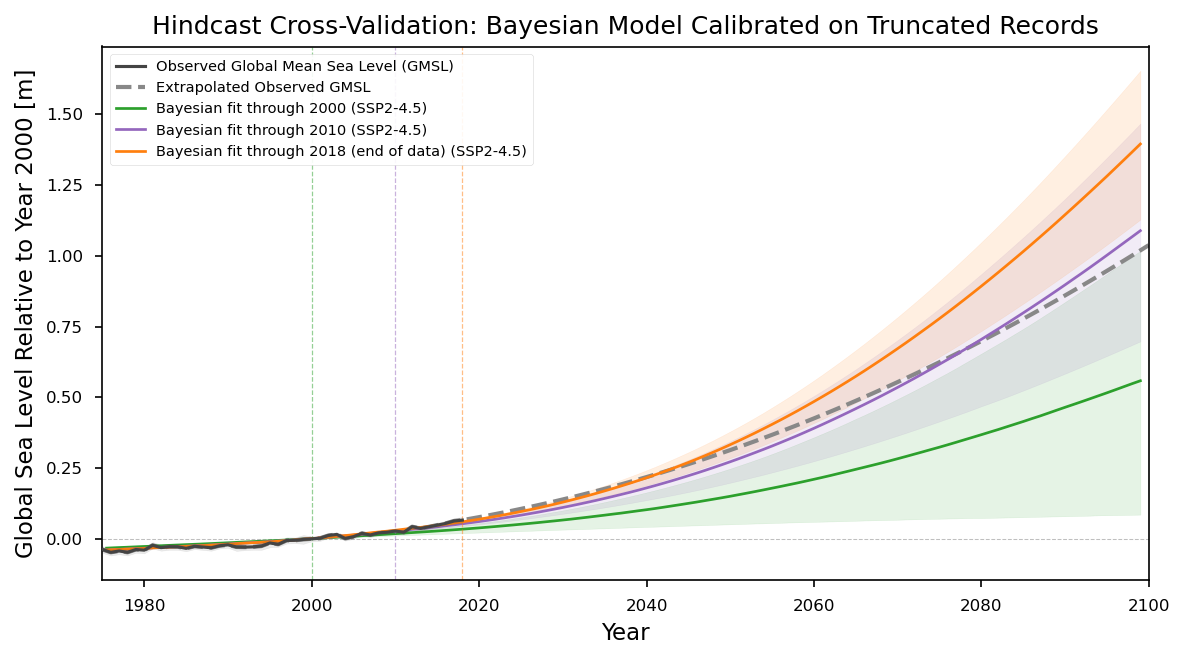

Figure 3 saved.


In [72]:
# ============================================================
# Figure 3: Hindcast cross-validation
# ============================================================

# --- Ensure kinematics extrapolation variables exist (from cell 8) ---
if 't_end' not in dir():
    EXTRAP_BW = 30
    kin = compute_kinematics(
        time=fred_time, value=fred_gmsl_rb,
        sigma=fred_gmsl_sigma, span_years=EXTRAP_BW,
    )
    rate_end, accel_end = kin.rate[-1], kin.accel[-1]
    rate_se_end, accel_se_end = kin.rate_se[-1], kin.accel_se[-1]
    t_end, H_end = kin.time[-1], fred_gmsl_rb[-1]
    t_extrap = np.arange(fred_time[0], 2101, dtype=float)
    dt_extrap = t_extrap - t_end
    quad_extrap = np.where(
        t_extrap <= t_end,
        np.interp(t_extrap, fred_time, fred_gmsl_rb),
        H_end + rate_end * dt_extrap + 0.5 * accel_end * dt_extrap**2,
    )

# Ensure color constants exist (from cell 12)
COLOR_OBS = COLOR_OBS if 'COLOR_OBS' in dir() else '#444444'
COLOR_EXTRAP = COLOR_EXTRAP if 'COLOR_EXTRAP' in dir() else '#888888'
SSP = SSP if 'SSP' in dir() else 'SSP2-4.5'

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.axhline(0, color='gray', ls='--', lw=0.5, alpha=0.5)

# Observations
mask_plot = (fred_time >= PLOT_YEAR_START) & (fred_time <= PLOT_YEAR_END)
ax.plot(fred_time[mask_plot], fred_gmsl_rb[mask_plot],
        color=COLOR_OBS, linewidth=1.5, zorder=5,
        label='Observed Global Mean Sea Level (GMSL)')
ax.fill_between(fred_time[mask_plot],
                fred_gmsl_rb[mask_plot] - 1.645 * fred_gmsl_sigma[mask_plot],
                fred_gmsl_rb[mask_plot] + 1.645 * fred_gmsl_sigma[mask_plot],
                color=COLOR_OBS, alpha=0.1, zorder=4)

# Kinematics extrapolation
mask_ext2 = (t_extrap >= PLOT_YEAR_START) & (t_extrap <= PLOT_YEAR_END)
ax.plot(t_extrap[mask_ext2], quad_extrap[mask_ext2],
        color=COLOR_EXTRAP, linewidth=2, linestyle='--',
        label='Extrapolated Observed GMSL')

# Hindcast projections
for cut_yr, hr in hindcast_results.items():
    hdf = hr['projection']
    ht = hdf['decimal_year'].values
    mask_h = (ht >= PLOT_YEAR_START) & (ht <= PLOT_YEAR_END)

    color = HINDCAST_COLORS[cut_yr]
    label_end = f' (end of data)' if cut_yr >= fred_time[-1] else ''
    ax.plot(ht[mask_h], hdf['gmsl'].values[mask_h],
            color=color, linewidth=1.3,
            label=f'Bayesian fit through {cut_yr}{label_end} ({SSP})')
    ax.fill_between(ht[mask_h],
                    hdf['gmsl_lower'].values[mask_h],
                    hdf['gmsl_upper'].values[mask_h],
                    color=color, alpha=0.12)

    # Mark the cutoff year
    cut_idx = np.argmin(np.abs(fred_time - cut_yr))
    if cut_idx < len(fred_gmsl_rb):
        ax.axvline(cut_yr, color=color, linewidth=0.6, linestyle='--',
                   alpha=0.5)

ax.set_xlim(PLOT_YEAR_START, PLOT_YEAR_END)
ax.set_xlabel('Year')
ax.set_ylabel('Global Sea Level Relative to Year 2000 [m]')
ax.set_title('Hindcast Cross-Validation: Bayesian Model Calibrated on Truncated Records')
ax.legend(loc='upper left', fontsize=7, frameon=True, framealpha=0.9)

fig.tight_layout()
fig.savefig('../figures/stats_v_process_fig3_hindcast.png',
            dpi=200, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

In [ ]:
# ============================================================
# Figure 4: Hindcast cross-validation + ISMIP6 models
# ============================================================

# --- Ensure kinematics extrapolation variables exist (from cell 8) ---
if 't_end' not in dir():
    EXTRAP_BW = 30
    kin = compute_kinematics(
        time=fred_time, value=fred_gmsl_rb,
        sigma=fred_gmsl_sigma, span_years=EXTRAP_BW,
    )
    rate_end, accel_end = kin.rate[-1], kin.accel[-1]
    rate_se_end, accel_se_end = kin.rate_se[-1], kin.accel_se[-1]
    t_end, H_end = kin.time[-1], fred_gmsl_rb[-1]
    t_extrap = np.arange(fred_time[0], 2101, dtype=float)
    dt_extrap = t_extrap - t_end
    quad_extrap = np.where(
        t_extrap <= t_end,
        np.interp(t_extrap, fred_time, fred_gmsl_rb),
        H_end + rate_end * dt_extrap + 0.5 * accel_end * dt_extrap**2,
    )

# Ensure color constants exist (from cell 12)
COLOR_OBS = COLOR_OBS if 'COLOR_OBS' in dir() else '#444444'
COLOR_EXTRAP = COLOR_EXTRAP if 'COLOR_EXTRAP' in dir() else '#888888'
SSP = SSP if 'SSP' in dir() else 'SSP2-4.5'

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.axhline(0, color='gray', ls='--', lw=0.5, alpha=0.5)

# Observations
mask_plot = (fred_time >= PLOT_YEAR_START) & (fred_time <= PLOT_YEAR_END)
ax.plot(fred_time[mask_plot], fred_gmsl_rb[mask_plot],
        color=COLOR_OBS, linewidth=1.5, zorder=5,
        label='Observed Global Mean Sea Level (GMSL)')
ax.fill_between(fred_time[mask_plot],
                fred_gmsl_rb[mask_plot] - 1.645 * fred_gmsl_sigma[mask_plot],
                fred_gmsl_rb[mask_plot] + 1.645 * fred_gmsl_sigma[mask_plot],
                color=COLOR_OBS, alpha=0.1, zorder=4)

# Kinematics extrapolation
mask_ext2 = (t_extrap >= PLOT_YEAR_START) & (t_extrap <= PLOT_YEAR_END)
ax.plot(t_extrap[mask_ext2], quad_extrap[mask_ext2],
        color=COLOR_EXTRAP, linewidth=2, linestyle='--',
        label='Extrapolated Observed GMSL')

# Hindcast projections
for cut_yr, hr in hindcast_results.items():
    hdf = hr['projection']
    ht = hdf['decimal_year'].values
    mask_h = (ht >= PLOT_YEAR_START) & (ht <= PLOT_YEAR_END)

    color = HINDCAST_COLORS[cut_yr]
    label_end = f' (end of data)' if cut_yr >= fred_time[-1] else ''
    ax.plot(ht[mask_h], hdf['gmsl'].values[mask_h],
            color=color, linewidth=1.3,
            label=f'Bayesian fit through {cut_yr}{label_end} ({SSP})')
    ax.fill_between(ht[mask_h],
                    hdf['gmsl_lower'].values[mask_h],
                    hdf['gmsl_upper'].values[mask_h],
                    color=color, alpha=0.12)

    # Mark the cutoff year
    cut_idx = np.argmin(np.abs(fred_time - cut_yr))
    if cut_idx < len(fred_gmsl_rb):
        ax.axvline(cut_yr, color=color, linewidth=0.6, linestyle='--',
                   alpha=0.5)

ax.set_xlim(PLOT_YEAR_START, PLOT_YEAR_END)
ax.set_xlabel('Year')
ax.set_ylabel('Global Sea Level Relative to Year 2000 [m]')
ax.set_title('Hindcast Cross-Validation: Bayesian Model Calibrated on Truncated Records')
ax.legend(loc='upper left', fontsize=7, frameon=True, framealpha=0.9)

fig.tight_layout()
fig.savefig('../figures/stats_v_process_fig4_hindcast_ismip6.png',
            dpi=200, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

In [73]:
# ============================================================
# Summary statistics table
# ============================================================
print('\n' + '='*70)
print('HINDCAST CROSS-VALIDATION SUMMARY')
print('='*70)
print(f'{"Cutoff":>8} {"RMSE (mm)":>12} {"Bias (mm)":>12} {"90% Coverage":>14}')
print('-'*50)
for cut_yr, hr in hindcast_results.items():
    print(f'{cut_yr:>8} {hr["rmse_mm"]:>12.1f} {hr["bias_mm"]:>12.1f} '
          f'{hr["coverage_90"]:>13.0%}')

print('\n' + '='*70)
print('PROJECTION COMPARISON AT 2050, 2070, AND 2100')
print('='*70)
rs_df = mc_results['scenarios'][SSP]
ipcc_df = ipcc_gmsl_rb[SSP]
for yr in [2050, 2070, 2100]:
    # Rate-and-state
    idx_r = np.argmin(np.abs(rs_df['decimal_year'].values - yr))
    r_med = rs_df['gmsl'].values[idx_r] * M_TO_MM
    r_lo = rs_df['gmsl_lower'].values[idx_r] * M_TO_MM
    r_hi = rs_df['gmsl_upper'].values[idx_r] * M_TO_MM
    # IPCC
    idx_i = np.argmin(np.abs(ipcc_df['decimal_year'].values - yr))
    i_med = ipcc_df['gmsl'].values[idx_i] * M_TO_MM
    i_lo = ipcc_df['gmsl_lower'].values[idx_i] * M_TO_MM
    i_hi = ipcc_df['gmsl_upper'].values[idx_i] * M_TO_MM
    print(f'\n{yr} ({SSP}):')
    print(f'  Rate-and-state:  {r_med:.0f} mm [{r_lo:.0f}–{r_hi:.0f}] (90% CI)')
    print(f'  IPCC:            {i_med:.0f} mm [{i_lo:.0f}–{i_hi:.0f}] (90% CI)')
    print(f'  Difference:      {r_med - i_med:+.0f} mm (Rate-and-state − IPCC)')


HINDCAST CROSS-VALIDATION SUMMARY
  Cutoff    RMSE (mm)    Bias (mm)   90% Coverage
--------------------------------------------------
    2000         15.5         11.3           22%
    2010          8.6          5.8           38%
    2018          nan          nan          nan%

PROJECTION COMPARISON AT 2050, 2070, AND 2100

2050 (SSP2-4.5):
  Rate-and-state:  322 mm [282–360] (90% CI)
  IPCC:            204 mm [156–317] (90% CI)
  Difference:      +118 mm (Rate-and-state − IPCC)

2070 (SSP2-4.5):
  Rate-and-state:  651 mm [566–739] (90% CI)
  IPCC:            331 mm [241–536] (90% CI)
  Difference:      +320 mm (Rate-and-state − IPCC)

2100 (SSP2-4.5):
  Rate-and-state:  1351 mm [1155–1562] (90% CI)
  IPCC:            555 mm [370–945] (90% CI)
  Difference:      +796 mm (Rate-and-state − IPCC)
